# Wasserstein-distance clustering of AA->AA substitutions on APEX MIC deltas

Clusters the 380 off-diagonal amino-acid substitutions by the 1-Wasserstein distance
between their **log2 MIC-ratio distributions** across all 34 bacterial strains in the
APEX prediction table.

For each substitution event we compute, per bacterial column:
`delta = log2(MIC_mutant) - log2(MIC_parent)`. All such deltas for a given AA->AA pair
(across every event of that pair AND every bacterium) are pooled into one 1D sample, and
pairs are compared with the 1-Wasserstein distance on those samples.

**Data**
- Parents: `results/data/all_in/peptides_apex.csv` (305k rows; 34 MIC columns).
- Mutants: `results/data/all_in/peptides_mutants_apex.csv` (~14 GB; streamed once and
  cached as parquet, filtered to mutants whose `parent` is in the chosen parent set).

**Style** follows `count_mic_changes.ipynb`: SOFT_BLUE / vlag palettes, square
white-gridded heatmaps, AA-group color bars and separators, clean typography.

**Outputs**
1. Wasserstein distance clustermap with dendrograms and cluster color sidebars.
2. 20x20 AA->AA cluster-assignment heatmap (chemical-type grouping with side bars).
3. Per-cluster centroid distributions of log2 MIC ratio.
4. 2D MDS embedding of the distance matrix, colored by cluster.


In [1]:
# === Imports ===
from __future__ import annotations
from pathlib import Path
from collections import defaultdict
import time, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Colormap, LinearSegmentedColormap
import seaborn as sns

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import MDS

sns.set_context("notebook")


## 1. Configuration and paths

In [2]:
def find_project_root(marker: str = "pep-compass", start: Path | None = None) -> Path:
    """Walk up from start to the pep-compass repo root, falling back to the parent
    that contains results/data/all_in."""
    here = (start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if cand.name == marker:
            return cand
    for cand in [here, *here.parents]:
        if (cand / "results" / "data" / "all_in").is_dir():
            return cand
    raise FileNotFoundError(f"Could not locate '{marker}' from {here}")


PROJECT_ROOT     = find_project_root()
PARENT_APEX_PATH = PROJECT_ROOT / "results/data/all_in/peptides_apex.csv"
MUTANT_APEX_PATH = PROJECT_ROOT / "results/data/all_in/peptides_mutants_apex.csv"
CACHE_DIR        = PROJECT_ROOT / "results/data/all_in/_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Pick one parent dataset to drive the analysis. The `dataset` column in peptides_apex
# is a `;`-separated tag list; we keep rows that include this exact tag.
DATASET_FILTER = "hydramp_veltri_negative"

MIN_EVENTS_PAIR = 5     # pairs with fewer events are flagged but kept
CHUNKSIZE       = 200_000

PARENT_CACHE = CACHE_DIR / f"parents_{DATASET_FILTER}.parquet"
MUTANT_CACHE = CACHE_DIR / f"mutants_{DATASET_FILTER}.parquet"

# Make the numba pairwise_wasserstein utility importable from anywhere.
UTILS_PATH = PROJECT_ROOT / "analysis"
if str(UTILS_PATH) not in sys.path:
    sys.path.insert(0, str(UTILS_PATH))

print(f"Project root:   {PROJECT_ROOT}")
print(f"Dataset filter: {DATASET_FILTER}")
print(f"Cache dir:      {CACHE_DIR}")


Project root:   C:\Users\Karol\Desktop\PepCompass\pep-compass
Dataset filter: hydramp_veltri_negative
Cache dir:      C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\all_in\_cache


## 2. Visual style helpers (ported from count_mic_changes)

In [3]:
AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A","V","L","I","M","F","W","P","G"],
        "polar":       ["S","T","Y","C","N","Q"],
        "charged":     ["K","R","H","D","E"],
    },
    "charge": {
        "positive": ["K","R","H"],
        "negative": ["D","E"],
        "neutral":  ["A","V","L","I","M","F","W","P","G","S","T","Y","C","N","Q"],
    },
    "chemical_type": {
        "aliphatic": ["G","A","V","L","I"],
        "aromatic":  ["F","Y","W"],
        "hydroxyl":  ["S","T","Y"],
        "acidic":    ["D","E"],
        "amide":     ["N","Q"],
        "basic":     ["K","R","H"],
        "sulfur":    ["C","M"],
        "imino":     ["P"],
    },
}
ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

SOFT_BLUE = LinearSegmentedColormap.from_list(
    "soft_blue",
    ["#f7fbff","#deebf7","#c6dbef","#9ecae1","#6baed6","#4292c6"],
)
SOFT_DIVERGING = sns.color_palette("vlag", as_cmap=True)


def _grouped_axis_order(aas, classification):
    if classification is None:
        return aas, [], []
    groups = AMINO_ACID_CLASSES[classification]
    sorted_aa, assigned, gsizes, gnames = [], set(), [], []
    for gn, mem in groups.items():
        pres = [aa for aa in aas if aa in mem and aa not in assigned]
        if pres:
            sorted_aa.extend(pres); assigned.update(pres)
            gsizes.append(len(pres)); gnames.append(gn)
    sorted_aa.extend([aa for aa in aas if aa not in assigned])
    return sorted_aa, gsizes, gnames


def _draw_group_bars(ax, df, gsizes, gnames, group_colors=None):
    if not gsizes:
        return
    boundaries = np.cumsum(gsizes)
    for b in boundaries[:-1]:
        ax.axhline(b, color="#9aa0a6", lw=1.0)
        ax.axvline(b, color="#9aa0a6", lw=1.0)
    total = len(df)
    mids = (boundaries - np.array(gsizes) / 2) / total
    sizes_ax = np.array(gsizes) / total
    if group_colors is None:
        palette = sns.color_palette("Set2", len(gnames))
        group_colors = {g: palette[i] for i, g in enumerate(gnames)}
    bar_t = 0.025; y_gap, x_gap, lab_gap = 0.045, 0.06, 0.012
    for mid, gn, gs in zip(mids, gnames, sizes_ax):
        col = group_colors.get(gn, "lightgray")
        y = 1.0 - mid
        ax.add_patch(plt.Rectangle((-(y_gap+bar_t), y-gs/2), bar_t, gs,
                                    transform=ax.transAxes, clip_on=False, color=col))
        ax.text(-(y_gap+bar_t)-lab_gap, y, gn, transform=ax.transAxes,
                rotation=90, ha="center", va="center", fontsize=9)
        ax.add_patch(plt.Rectangle((mid-gs/2, -(x_gap+bar_t)), gs, bar_t,
                                    transform=ax.transAxes, clip_on=False, color=col))
        ax.text(mid, -(x_gap+bar_t)-lab_gap, gn, transform=ax.transAxes,
                rotation=90, ha="center", va="top", fontsize=9)
    ax.yaxis.set_label_coords(-(y_gap+bar_t)-0.06, 0.5)


## 3. Load parent APEX, filter to the chosen dataset

The `dataset` column is a `;`-separated tag list; we keep rows where `DATASET_FILTER`
appears as one of the tags. We then keep the `sequence` plus the 34 bacterial MIC
columns.

In [4]:
META_COLS = ("sequence", "within_dataset_id", "source_file", "dataset")

if PARENT_CACHE.exists():
    print(f"Loading parents from cache {PARENT_CACHE.name}")
    parents = pd.read_parquet(PARENT_CACHE)
else:
    t0 = time.time()
    parents = pd.read_csv(PARENT_APEX_PATH)
    mask = parents["dataset"].fillna("").apply(
        lambda s: DATASET_FILTER in s.split(";")
    )
    parents = parents.loc[mask].reset_index(drop=True)
    parents.to_parquet(PARENT_CACHE, index=False)
    print(f"Filtered parents in {time.time()-t0:.1f}s; cached to {PARENT_CACHE.name}")

BACT_COLS = [c for c in parents.columns if c not in META_COLS]
print(f"Parent rows: {len(parents):,}")
print(f"Bacterial MIC columns: {len(BACT_COLS)}")

# Keyed lookup for the merge in cell 4
parent_mic = parents.set_index("sequence")[BACT_COLS]


Loading parents from cache parents_hydramp_veltri_negative.parquet
Parent rows: 854
Bacterial MIC columns: 34


## 4. Load mutants -- chunked stream + parquet cache

The full mutants file (`peptides_mutants_apex.csv`) is ~14 GB. We stream it once,
keeping only rows whose `parent` is in our filtered parent set, and cache the result as
parquet. Subsequent runs read the cache directly (~MB).

In [5]:
if MUTANT_CACHE.exists():
    print(f"Loading mutants from cache {MUTANT_CACHE.name}")
    mutants = pd.read_parquet(MUTANT_CACHE)
else:
    print(f"Streaming {MUTANT_APEX_PATH.name} -> cache (chunksize={CHUNKSIZE:,}) ...")
    t0 = time.time()
    parent_set = set(parents["sequence"])
    keep = []
    scanned = 0
    for i, chunk in enumerate(pd.read_csv(MUTANT_APEX_PATH, chunksize=CHUNKSIZE)):
        scanned += len(chunk)
        m = chunk["parent"].isin(parent_set)
        if m.any():
            keep.append(chunk.loc[m].copy())
        if (i + 1) % 20 == 0:
            print(f"  chunk {i+1}: scanned {scanned:,}", flush=True)
    mutants = pd.concat(keep, ignore_index=True) if keep else pd.DataFrame()
    mutants.to_parquet(MUTANT_CACHE, index=False)
    print(f"Streamed in {time.time()-t0:.1f}s; cached to {MUTANT_CACHE.name}")

print(f"Mutant rows kept: {len(mutants):,}")
print(f"Distinct parents covered: {mutants['parent'].nunique():,}")
print(f"Distinct mutant sequences: {mutants['mutant'].nunique():,}")


Loading mutants from cache mutants_hydramp_veltri_negative.parquet
Mutant rows kept: 77,297


Distinct parents covered: 854


Distinct mutant sequences: 23,669


## 5. Derive substitutions and log2 MIC deltas

Drop padding rows and self-mutations, identify the changed residue at `position`, then
subtract `log2(parent MIC)` (looked up by parent sequence) from `log2(mutant MIC)` for
every bacterial column. Each event ends up with a 34-vector of log-ratios.

In [6]:
m = mutants.copy()
m = m.dropna(subset=["parent","mutant","position"])
m = m[(m["position"] < m["parent"].str.len()) & (m["position"] < m["mutant"].str.len())]
m = m[m["parent"] != m["mutant"]]
pos = m["position"].astype(int)
m = m.assign(
    from_aa=[s[i] for s, i in zip(m["parent"], pos)],
    to_aa=  [s[i] for s, i in zip(m["mutant"], pos)],
)
m = m[m["from_aa"] != m["to_aa"]].reset_index(drop=True)

# Per-event mutant MIC (already in `m`) and matching parent MIC (lookup).
mut_mic = m[BACT_COLS].to_numpy(dtype=np.float64)
par_mic = parent_mic.loc[m["parent"].to_numpy()].to_numpy(dtype=np.float64)

# Drop events with any non-positive MIC so the log is defined.
valid = (mut_mic > 0).all(axis=1) & (par_mic > 0).all(axis=1)
m = m.loc[valid].reset_index(drop=True)
mut_mic = mut_mic[valid]
par_mic = par_mic[valid]

deltas = np.log2(mut_mic) - np.log2(par_mic)   # shape (N_events, 34)
print(f"Substitution events kept: {len(m):,}")
print(f"Per-event delta matrix:   {deltas.shape}")
print(f"Delta value range:        min={deltas.min():.3f}  mean={deltas.mean():.3f}  max={deltas.max():.3f}")


Substitution events kept: 57,182
Per-event delta matrix:   (57182, 34)
Delta value range:        min=-2.770  mean=-0.013  max=2.785


## 6. Per-pair delta distributions

For each off-diagonal AA->AA pair we pool every per-bacterium delta from every event of
that pair into a single 1D sample. Empty pairs (no events) get a tiny placeholder so the
distance matrix stays well-defined; they are flagged in the summary.

In [7]:
pairs: list[tuple[str,str]] = []
arrays: list[np.ndarray] = []
empty_pairs: list[tuple[str,str]] = []
event_counts: list[int] = []

# Group event indices by (from_aa, to_aa) once.
groups = m.groupby(["from_aa","to_aa"], sort=False).indices

for a in ALL_AA:
    for b in ALL_AA:
        if a == b:
            continue
        idx = groups.get((a, b))
        if idx is None or len(idx) == 0:
            empty_pairs.append((a, b))
            arr = np.array([0.0])  # placeholder
            n_events = 0
        else:
            arr = deltas[idx].reshape(-1)   # flatten all 34 bacterium values for all events
            n_events = len(idx)
        pairs.append((a, b))
        arrays.append(arr.astype(np.float64))
        event_counts.append(n_events)

sizes = np.array(event_counts)
print(f"Off-diagonal pairs:        {len(pairs)} (of 380)")
print(f"Pairs with no events:      {len(empty_pairs)} -> {empty_pairs}")
print(f"Events per pair: min/median/max = {sizes.min()} / {int(np.median(sizes))} / {sizes.max()}")
print(f"Pairs with < {MIN_EVENTS_PAIR} events:     {(sizes < MIN_EVENTS_PAIR).sum()}")


Off-diagonal pairs:        380 (of 380)
Pairs with no events:      17 -> [('A', 'H'), ('A', 'Y'), ('D', 'H'), ('D', 'I'), ('D', 'P'), ('D', 'Q'), ('D', 'R'), ('D', 'Y'), ('H', 'D'), ('H', 'W'), ('N', 'D'), ('S', 'Y'), ('T', 'D'), ('T', 'M'), ('T', 'R'), ('Y', 'D'), ('Y', 'E')]
Events per pair: min/median/max = 0 / 46 / 2234
Pairs with < 5 events:     35


## 7. Pairwise 1-Wasserstein distance matrix

Uses the project's numba+parallel implementation in
`analysis/utils/plotting/wasserstein_distance.py` (raw values, no binning). Falls back
to a scipy loop if numba import fails.

In [8]:
try:
    from utils.plotting.wasserstein_distance import pairwise_wasserstein
    print("Using numba+parallel pairwise_wasserstein from analysis/utils/plotting/")
    t0 = time.time()
    D = pairwise_wasserstein(arrays)
    print(f"  computed in {time.time()-t0:.1f}s")
except Exception as e:
    print(f"Numba path failed ({e!r}); falling back to scipy loop.")
    from scipy.stats import wasserstein_distance
    M = len(arrays)
    D = np.zeros((M, M), dtype=np.float64)
    t0 = time.time()
    for i in range(M):
        ui = arrays[i]
        for j in range(i + 1, M):
            v = wasserstein_distance(ui, arrays[j])
            D[i, j] = v; D[j, i] = v
    print(f"  computed in {time.time()-t0:.1f}s")

print(f"D shape: {D.shape}")
print(f"D stats: min={D.min():.4f}  mean={D.mean():.4f}  max={D.max():.4f}")


Using numba+parallel pairwise_wasserstein from analysis/utils/plotting/


C:\Users\Karol\Desktop\PepCompass\pep-compass\analysis\utils\plotting\wasserstein_distance.py:84: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  u_vals = values_list[i]


  computed in 46.1s
D shape: (380, 380)
D stats: min=0.0000  mean=0.0491  max=0.5031


## 8. Hierarchical clustering (average linkage, multiple cut levels)

In [9]:
Z = linkage(squareform(D), method="average")
LEVELS = [6, 12, 20]
clusters_by_level = {k: fcluster(Z, k, criterion="maxclust") for k in LEVELS}

for k, cl in clusters_by_level.items():
    sizes_k = np.bincount(cl)[1:]
    head = sorted(sizes_k.tolist(), reverse=True)[:10]
    tail = " ..." if len(sizes_k) > 10 else ""
    print(f"k={k:>2}: {len(sizes_k)} clusters, sizes (desc) = {head}{tail}")

PRIMARY_K = 12
primary_clusters = clusters_by_level[PRIMARY_K]


k= 6: 6 clusters, sizes (desc) = [366, 10, 1, 1, 1, 1]
k=12: 12 clusters, sizes (desc) = [228, 59, 59, 14, 8, 5, 2, 1, 1, 1] ...
k=20: 20 clusters, sizes (desc) = [228, 53, 42, 13, 11, 6, 4, 4, 4, 3] ...


## 9. Visualization 1 -- distance clustermap with dendrograms

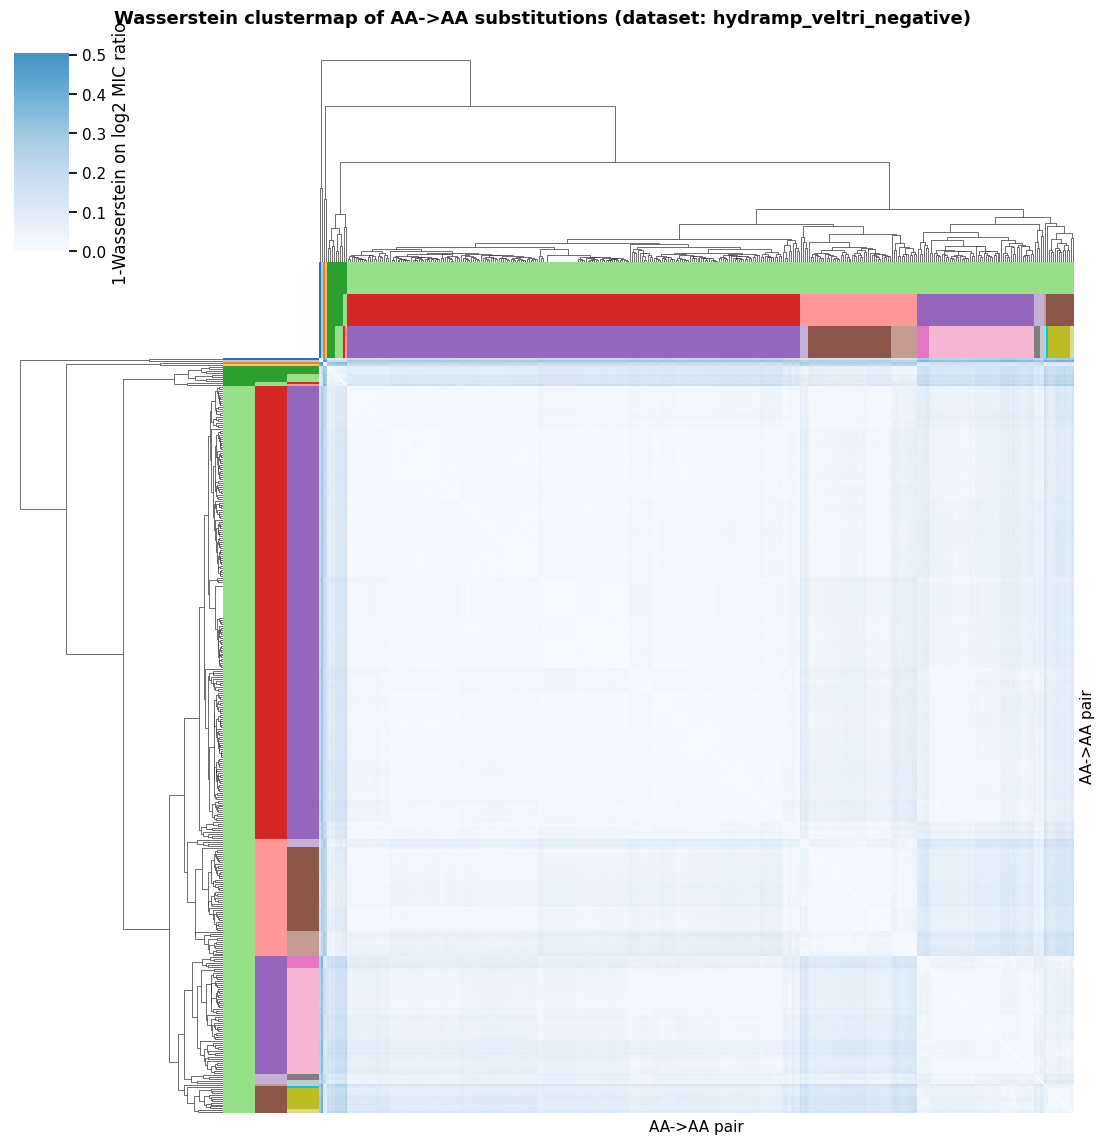

In [10]:
dist_df = pd.DataFrame(
    D,
    index=[f"{a}>{b}" for a,b in pairs],
    columns=[f"{a}>{b}" for a,b in pairs],
)

row_color_levels = []
for k in LEVELS:
    cl = clusters_by_level[k]
    palette = sns.color_palette("tab20", n_colors=max(20, len(set(cl))))
    cmap_k = {c: palette[i % len(palette)] for i, c in enumerate(sorted(set(cl)))}
    row_color_levels.append(pd.Series([cmap_k[c] for c in cl], name=f"k={k}"))

g = sns.clustermap(
    dist_df,
    row_linkage=Z, col_linkage=Z,
    cmap=SOFT_BLUE,
    row_colors=row_color_levels,
    col_colors=row_color_levels,
    figsize=(11, 11),
    xticklabels=False, yticklabels=False,
    cbar_kws={"label": "1-Wasserstein on log2 MIC ratio"},
    linewidths=0,
)
g.ax_heatmap.set_xlabel("AA->AA pair", fontsize=11)
g.ax_heatmap.set_ylabel("AA->AA pair", fontsize=11)
g.figure.suptitle(
    f"Wasserstein clustermap of AA->AA substitutions (dataset: {DATASET_FILTER})",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.show()


## 10. Visualization 2 -- AA->AA cluster-assignment heatmap

20x20 grid of cluster IDs, axes grouped by `chemical_type` with side bars.

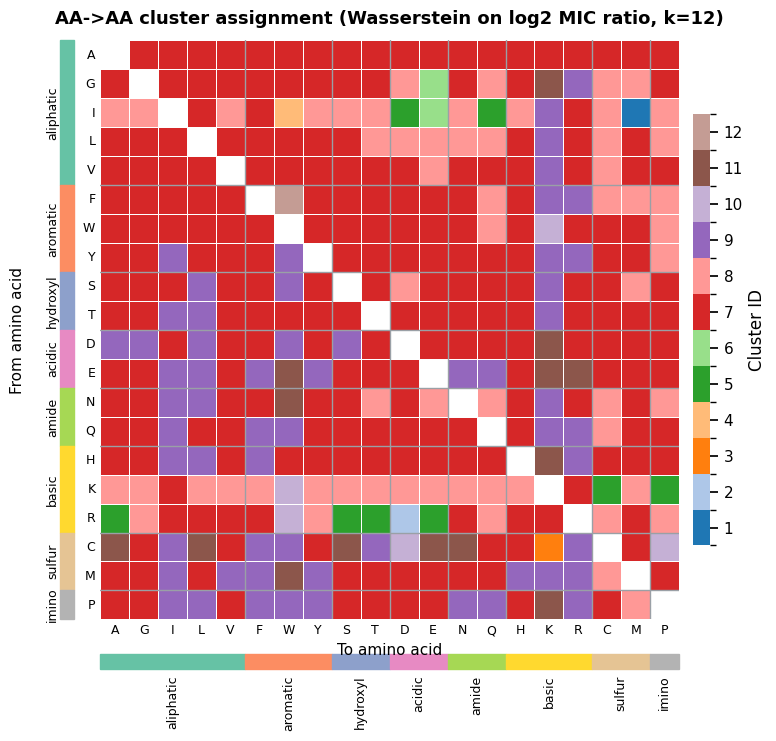

In [11]:
def plot_cluster_assignment(pairs, clusters, classification="chemical_type",
                            figsize=(9, 8), title=None):
    A = len(ALL_AA)
    mat = np.full((A, A), np.nan)
    idx = {aa: i for i, aa in enumerate(ALL_AA)}
    for (a, b), c in zip(pairs, clusters):
        mat[idx[a], idx[b]] = c
    df = pd.DataFrame(mat, index=ALL_AA, columns=ALL_AA)

    uniq = sorted({int(c) for c in clusters})
    palette = sns.color_palette("tab20", n_colors=max(20, len(uniq)))
    cmap = mcolors.ListedColormap(palette[:len(uniq)])
    boundaries = np.arange(min(uniq), max(uniq) + 2) - 0.5
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)

    sorted_aa, gsizes, gnames = _grouped_axis_order(list(df.index), classification)
    df = df.loc[sorted_aa, sorted_aa]

    mask = df.isna()
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df, cmap=cmap, norm=norm, mask=mask, square=True,
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"shrink": 0.7, "aspect": 25, "pad": 0.02, "label": "Cluster ID"},
    )
    cbar = ax.collections[0].colorbar
    cbar.set_ticks(uniq); cbar.set_ticklabels([str(c) for c in uniq])
    ax.set_title(title or f"AA->AA cluster assignment (k={len(uniq)})",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("To amino acid", fontsize=11)
    ax.set_ylabel("From amino acid", fontsize=11)
    ax.tick_params(axis="both", labelsize=9, length=0)
    plt.setp(ax.get_yticklabels(), rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=0)
    _draw_group_bars(ax, df, gsizes, gnames)
    plt.show()
    return df

_ = plot_cluster_assignment(
    pairs, primary_clusters,
    classification="chemical_type",
    title=f"AA->AA cluster assignment (Wasserstein on log2 MIC ratio, k={PRIMARY_K})",
)


## 11. Visualization 3 -- per-cluster centroid distributions

For each cluster, pool every log2 MIC ratio value from every event of every member pair
across every bacterium, and show the resulting density. The dashed line marks the
cluster mean.

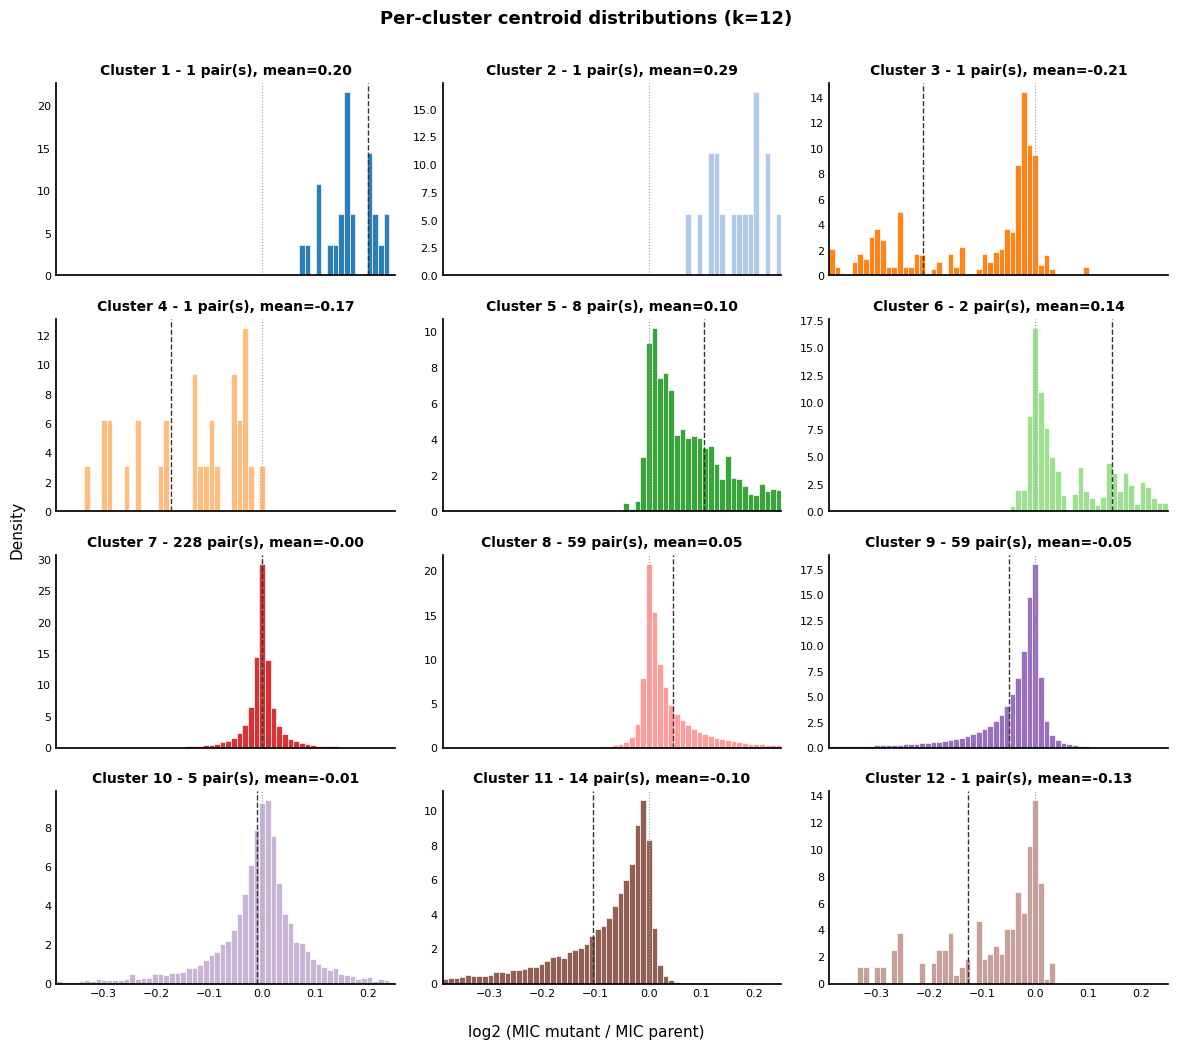

In [12]:
def cluster_event_deltas(arrays, clusters):
    bucket = defaultdict(list)
    for arr, c in zip(arrays, clusters):
        bucket[int(c)].append(arr)
    return {c: np.concatenate(vs) for c, vs in bucket.items()}


def plot_cluster_centroids(deltas_by_cluster, clusters, xrange=None):
    keys = sorted(deltas_by_cluster)
    K = len(keys)
    ncols = 3
    nrows = int(np.ceil(K / ncols))
    palette = sns.color_palette("tab20", n_colors=max(20, K))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 2.6*nrows), sharex=True)
    axes = np.atleast_2d(axes).ravel()
    sizes = {c: int(np.sum(clusters == c)) for c in keys}
    # Auto x-range from 1st/99th percentile of all data for legibility
    if xrange is None:
        all_v = np.concatenate(list(deltas_by_cluster.values()))
        lo, hi = np.percentile(all_v, [1, 99])
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        xrange = (lo - pad, hi + pad)
    for ax, c in zip(axes, keys):
        vals = deltas_by_cluster[c]
        ax.hist(vals, bins=60, range=xrange,
                color=palette[(c-1) % len(palette)],
                edgecolor="white", linewidth=0.5, alpha=0.95, density=True)
        ax.axvline(0.0, color="#9aa0a6", lw=0.8, ls=":")    # zero-effect reference
        ax.axvline(vals.mean(), color="#333", lw=1.0, ls="--")
        ax.set_title(f"Cluster {c} - {sizes[c]} pair(s), mean={vals.mean():.2f}",
                     fontsize=10, fontweight="bold")
        ax.set_xlim(*xrange)
        ax.tick_params(axis="both", labelsize=8, length=0)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
    for ax in axes[len(keys):]:
        ax.axis("off")
    fig.supxlabel("log2 (MIC mutant / MIC parent)", fontsize=11)
    fig.supylabel("Density", fontsize=11)
    fig.suptitle(f"Per-cluster centroid distributions (k={K})",
                 fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    plt.show()


deltas_by_cluster = cluster_event_deltas(arrays, primary_clusters)
plot_cluster_centroids(deltas_by_cluster, primary_clusters)


## 12. Visualization 4 -- 2D MDS embedding

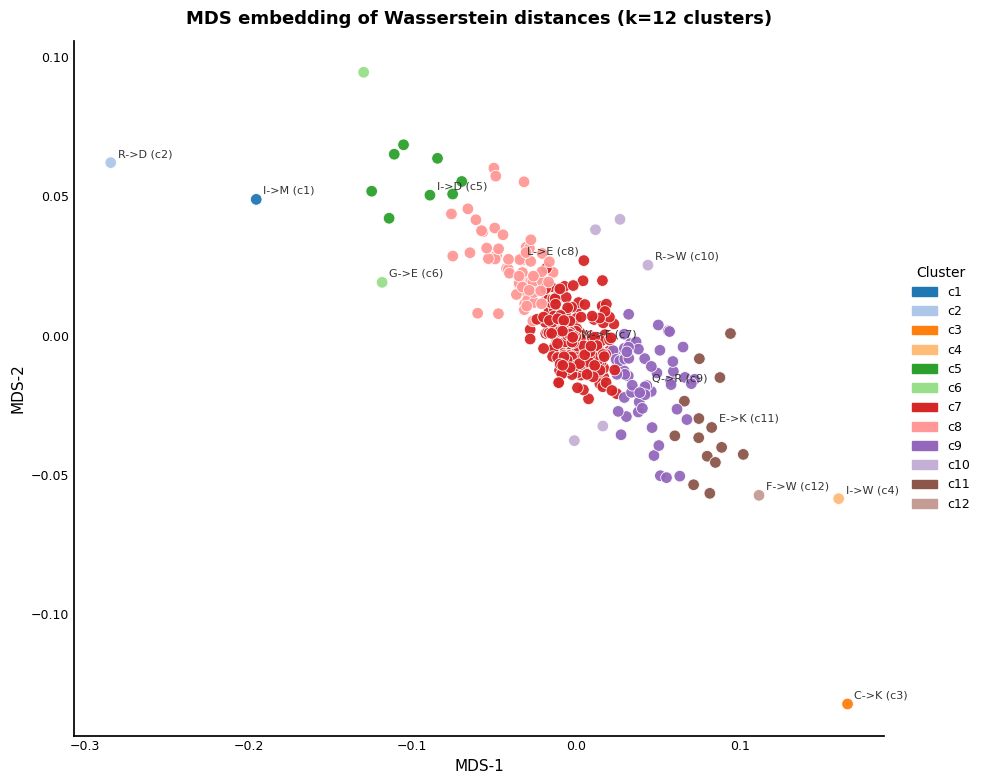

In [13]:
mds = MDS(n_components=2, dissimilarity="precomputed",
          random_state=0, n_init=4, normalized_stress="auto")
coords = mds.fit_transform(D)

palette = sns.color_palette("tab20", n_colors=max(20, len(set(primary_clusters))))
cluster_color = {c: palette[(c-1) % len(palette)] for c in sorted(set(primary_clusters))}
colors = [cluster_color[c] for c in primary_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:,0], coords[:,1], c=colors, s=70,
           edgecolor="white", linewidth=0.6, alpha=0.95)

for c in sorted(set(primary_clusters)):
    mask = primary_clusters == c
    if mask.sum() == 0:
        continue
    sub = coords[mask]
    centroid = sub.mean(axis=0)
    closest = np.argmin(((sub - centroid) ** 2).sum(axis=1))
    i = np.where(mask)[0][closest]
    a, b = pairs[i]
    ax.annotate(f"{a}->{b} (c{c})", (coords[i,0], coords[i,1]),
                xytext=(5, 4), textcoords="offset points", fontsize=8, color="#333")

ax.set_title(f"MDS embedding of Wasserstein distances (k={PRIMARY_K} clusters)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("MDS-1", fontsize=11)
ax.set_ylabel("MDS-2", fontsize=11)
ax.tick_params(axis="both", labelsize=9, length=0)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

handles = [mpatches.Patch(color=cluster_color[c], label=f"c{c}")
           for c in sorted(set(primary_clusters))]
ax.legend(handles=handles, title="Cluster", loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9, title_fontsize=10)
fig.tight_layout()
plt.show()


## 13. Summary table

Per-cluster size, mean and median log2 MIC ratio, and example AA->AA members.

In [14]:
summary_rows = []
for c in sorted(set(primary_clusters)):
    members = [f"{a}>{b}" for (a,b), cc in zip(pairs, primary_clusters) if cc == c]
    vals = deltas_by_cluster[c]
    summary_rows.append({
        "cluster":       int(c),
        "n_pairs":       len(members),
        "n_events":      int(np.sum([event_counts[i] for i, cc in enumerate(primary_clusters) if cc == c])),
        "n_delta_values": int(vals.size),
        "mean_log2_ratio":   round(float(vals.mean()), 3),
        "median_log2_ratio": round(float(np.median(vals)), 3),
        "examples": ", ".join(members[:8]) + (" ..." if len(members) > 8 else ""),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("mean_log2_ratio").reset_index(drop=True)
summary_df


,cluster,n_pairs,n_events,n_delta_values,mean_log2_ratio,median_log2_ratio,examples
0,3,1,27,918,-0.213,-0.102,C>K
1,4,1,15,510,-0.171,-0.130,I>W
2,12,1,10,340,-0.126,-0.058,F>W
3,11,14,1916,65144,-0.104,-0.054,"C>A, C>E, C>L, C>N, C>S, D>K, E>K, E>R ..."
4,9,59,18732,636888,-0.050,-0.018,"C>F, C>I, C>R, C>T, C>W, D>A, D>G, D>L ..."
5,10,5,655,22270,-0.010,0.000,"C>D, C>P, K>W, R>W, W>K"
6,7,228,26837,912475,-0.000,-0.000,"A>C, A>D, A>E, A>F, A>G, A>H, A>I, A>K ..."
7,8,59,8621,293114,0.046,0.015,"F>C, F>M, F>P, F>Q, G>C, G>D, G>M, G>Q ..."
8,5,8,292,9928,0.105,0.066,"I>D, I>Q, K>C, K>P, R>A, R>E, R>S, R>T"
9,6,2,59,2006,0.145,0.082,"G>E, I>E"


---

# 14. Extension: position-aware Wasserstein clustering on a wider dataset union

The previous sections gather every event of an AA->AA pair into a 1D distribution of
log2 MIC ratios; position is discarded. That has two limitations:

1. Two AA->AA substitutions that happen at the *same* sequence positions (because both
   are enumerated as alternative single-residue mutants of the same parent) end up with
   highly correlated event sets and may be clustered together purely because of shared
   context, not because the substitution effects are similar.
2. The position itself carries biology -- a substitution near the N-terminus of an AMP
   typically has a very different effect from the same substitution mid-helix.

This extension fixes both. We:
- **Widen the parent set** to the union of `hydramp_veltri_negative + hydramp_veltri_positive +
  hydramp_dbaasp_clean + hydramp_mic_data` (~6.3k parents instead of 854) and rebuild the cache
  for that union.
- **Replace the 1D feature with a 2D feature**: for each substitution event we compute
  `(relpos, mean_log2_ratio)`, where `mean_log2_ratio` is the mean of the 34 per-bacterium
  log2 ratios for that event. Including position in the feature naturally resolves the
  same-site ambiguity: two pairs at the same `relpos` are now only clustered together if
  their `mean_log2_ratio` also agrees.
- **Use Sliced Wasserstein in 2D**: project both 2D point clouds onto many random unit
  directions, average the 1D Wasserstein distance across projections. Each projection is
  handled by the existing numba `pairwise_wasserstein` util, so the whole 2D pairwise
  matrix is just `n_projections` calls of that util plus an average.
- **Sanity-check with a Mantel-style correlation** between the new 2D-distance matrix
  and the 1D-only matrix from earlier in the notebook -- if position adds real signal
  the two matrices should diverge meaningfully.


## 14.1 Build / load the extended-dataset cache

In [15]:
EXT_DATASETS = (
    "hydramp_veltri_negative",
    "hydramp_veltri_positive",
    "hydramp_dbaasp_clean",
    "hydramp_mic_data",
)
EXT_TAG = "ext_" + "_".join(d.replace("hydramp_", "") for d in EXT_DATASETS)
EXT_PARENT_CACHE = CACHE_DIR / f"parents_{EXT_TAG}.parquet"
EXT_MUTANT_CACHE = CACHE_DIR / f"mutants_{EXT_TAG}.parquet"

target_set = set(EXT_DATASETS)

if EXT_PARENT_CACHE.exists():
    print(f"Loading extended parents from cache {EXT_PARENT_CACHE.name}")
    parents_ext = pd.read_parquet(EXT_PARENT_CACHE)
else:
    t0 = time.time()
    parents_ext = pd.read_csv(PARENT_APEX_PATH)
    mask = parents_ext["dataset"].fillna("").apply(
        lambda s: any(t in target_set for t in s.split(";"))
    )
    parents_ext = parents_ext.loc[mask].reset_index(drop=True)
    parents_ext.to_parquet(EXT_PARENT_CACHE, index=False)
    print(f"Filtered extended parents in {time.time()-t0:.1f}s; cached.")

print(f"Extended parent rows: {len(parents_ext):,}")
parent_mic_ext = parents_ext.set_index("sequence")[BACT_COLS]

if EXT_MUTANT_CACHE.exists():
    print(f"Loading extended mutants from cache {EXT_MUTANT_CACHE.name}")
    mutants_ext = pd.read_parquet(EXT_MUTANT_CACHE)
else:
    print(f"Streaming {MUTANT_APEX_PATH.name} (chunksize={CHUNKSIZE:,}) for {len(target_set)} datasets ...")
    t0 = time.time()
    parent_set_ext = set(parents_ext["sequence"])
    keep = []
    for i, chunk in enumerate(pd.read_csv(MUTANT_APEX_PATH, chunksize=CHUNKSIZE)):
        m = chunk["parent"].isin(parent_set_ext)
        if m.any():
            keep.append(chunk.loc[m].copy())
    mutants_ext = pd.concat(keep, ignore_index=True) if keep else pd.DataFrame()
    mutants_ext.to_parquet(EXT_MUTANT_CACHE, index=False)
    print(f"Streamed extended mutants in {time.time()-t0:.1f}s; cached.")

print(f"Extended mutant rows: {len(mutants_ext):,}")
print(f"Distinct parents covered: {mutants_ext['parent'].nunique():,}")


Loading extended parents from cache parents_ext_veltri_negative_veltri_positive_dbaasp_clean_mic_data.parquet
Extended parent rows: 6,371
Loading extended mutants from cache mutants_ext_veltri_negative_veltri_positive_dbaasp_clean_mic_data.parquet
Extended mutant rows: 328,631


Distinct parents covered: 6,371


## 14.2 Derive substitutions and 2D `(relpos, mean log2 ratio)` features

`mean_log2_ratio` summarises an event's effect across all 34 bacterial strains with a
single number. `relpos = position / (len(parent) - 1)` is in `[0, 1]` so the two axes
live on comparable scales (after rescaling below).

In [16]:
me = mutants_ext.copy()
me = me.dropna(subset=["parent","mutant","position"])
me = me[(me["position"] < me["parent"].str.len()) & (me["position"] < me["mutant"].str.len())]
me = me[me["parent"] != me["mutant"]]
pos = me["position"].astype(int)
me = me.assign(
    from_aa=[s[i] for s, i in zip(me["parent"], pos)],
    to_aa=  [s[i] for s, i in zip(me["mutant"], pos)],
    plen=   me["parent"].str.len(),
)
me = me[me["from_aa"] != me["to_aa"]].reset_index(drop=True)

mut_mic_e = me[BACT_COLS].to_numpy(dtype=np.float64)
par_mic_e = parent_mic_ext.loc[me["parent"].to_numpy()].to_numpy(dtype=np.float64)
valid = (mut_mic_e > 0).all(axis=1) & (par_mic_e > 0).all(axis=1)
me = me.loc[valid].reset_index(drop=True)
mut_mic_e = mut_mic_e[valid]
par_mic_e = par_mic_e[valid]

deltas_e = np.log2(mut_mic_e) - np.log2(par_mic_e)        # (N, 34)
mean_log2 = deltas_e.mean(axis=1)                          # (N,)
relpos    = me["position"].to_numpy(dtype=np.float64) / (me["plen"].to_numpy(dtype=np.float64) - 1)

# 2D feature per event: (relpos, mean_log2_ratio).  Scaled so both axes have unit IQR.
features = np.stack([relpos, mean_log2], axis=1)             # (N, 2)
iqr = np.subtract(*np.percentile(features, [75, 25], axis=0))
iqr[iqr == 0] = 1.0
features_scaled = features / iqr                              # rescaled for SW

print(f"Extended substitution events kept: {len(me):,}")
print(f"relpos range:           [{features[:,0].min():.3f}, {features[:,0].max():.3f}]")
print(f"mean_log2_ratio range:  [{features[:,1].min():.3f}, {features[:,1].max():.3f}]")
print(f"IQR-scaled axes:        relpos iqr={iqr[0]:.3f}  delta iqr={iqr[1]:.3f}")


Extended substitution events kept: 234,727
relpos range:           [0.000, 1.000]
mean_log2_ratio range:  [-2.275, 2.581]
IQR-scaled axes:        relpos iqr=0.371  delta iqr=0.117


## 14.3 Per-pair 2D point clouds + Sliced-Wasserstein distance matrix

Sliced Wasserstein on `n_proj` random 1D projections of the 2D cloud:
`SW(X, Y) = mean_k W_1(X @ d_k, Y @ d_k)`.  Each projection becomes a 1D pairwise
problem that the existing numba `pairwise_wasserstein` solves in parallel.

In [17]:
# Group event indices by (from_aa, to_aa) for the extended set
groups_ext = me.groupby(["from_aa","to_aa"], sort=False).indices

pairs_ext: list[tuple[str,str]] = []
clouds_2d: list[np.ndarray] = []
event_counts_ext: list[int] = []

for a in ALL_AA:
    for b in ALL_AA:
        if a == b: continue
        idx = groups_ext.get((a, b))
        if idx is None or len(idx) == 0:
            cloud = np.array([[0.5, 0.0]])  # placeholder
            n = 0
        else:
            cloud = features_scaled[idx]
            n = len(idx)
        pairs_ext.append((a, b))
        clouds_2d.append(cloud.astype(np.float64))
        event_counts_ext.append(n)

sizes_ext = np.array(event_counts_ext)
print(f"Off-diagonal pairs: {len(pairs_ext)}")
print(f"Pairs with no events: {int((sizes_ext == 0).sum())}")
print(f"Events per pair: min/median/max = {sizes_ext.min()} / {int(np.median(sizes_ext))} / {sizes_ext.max()}")
print(f"Pairs with < {MIN_EVENTS_PAIR} events: {int((sizes_ext < MIN_EVENTS_PAIR).sum())}")


Off-diagonal pairs: 380
Pairs with no events: 2
Events per pair: min/median/max = 0 / 193 / 6616
Pairs with < 5 events: 8


In [18]:
# Sliced-Wasserstein on 2D point clouds using the existing numba 1D pairwise util.
N_PROJ = 30
SW_RNG = 0

rng = np.random.default_rng(SW_RNG)
thetas = rng.uniform(0.0, np.pi, N_PROJ)
proj_dirs = np.stack([np.cos(thetas), np.sin(thetas)], axis=1)   # (n_proj, 2)

from utils.plotting.wasserstein_distance import pairwise_wasserstein as _pw1d

M = len(clouds_2d)
D_sw = np.zeros((M, M), dtype=np.float64)

print(f"Computing Sliced-Wasserstein on M={M} clouds with n_proj={N_PROJ} ...")
t0 = time.time()
for k in range(N_PROJ):
    proj_clouds = [X @ proj_dirs[k] for X in clouds_2d]
    Dk = _pw1d(proj_clouds)
    D_sw += Dk
    if (k + 1) % 5 == 0:
        print(f"  projection {k+1}/{N_PROJ}  elapsed {time.time()-t0:.1f}s", flush=True)
D_sw /= N_PROJ
print(f"D_sw shape: {D_sw.shape}  total elapsed {time.time()-t0:.1f}s")
print(f"D_sw stats: min={D_sw.min():.4f}  mean={D_sw.mean():.4f}  max={D_sw.max():.4f}")


Computing Sliced-Wasserstein on M=380 clouds with n_proj=30 ...


  projection 5/30  elapsed 8.6s


  projection 10/30  elapsed 17.7s


  projection 15/30  elapsed 26.1s


  projection 20/30  elapsed 35.4s


  projection 25/30  elapsed 45.4s


  projection 30/30  elapsed 56.5s


D_sw shape: (380, 380)  total elapsed 56.5s
D_sw stats: min=0.0000  mean=0.7594  max=4.8622


## 14.4 Hierarchical clustering on the position-aware matrix

In [19]:
Z_ext = linkage(squareform(D_sw), method="average")
clusters_by_level_ext = {k: fcluster(Z_ext, k, criterion="maxclust") for k in LEVELS}
for k, cl in clusters_by_level_ext.items():
    s = np.bincount(cl)[1:]
    head = sorted(s.tolist(), reverse=True)[:10]
    tail = " ..." if len(s) > 10 else ""
    print(f"k={k:>2}: {len(s)} clusters, sizes (desc) = {head}{tail}")
primary_clusters_ext = clusters_by_level_ext[PRIMARY_K]


k= 6: 6 clusters, sizes (desc) = [346, 11, 11, 9, 2, 1]
k=12: 12 clusters, sizes (desc) = [187, 121, 28, 10, 9, 9, 8, 2, 2, 2] ...
k=20: 20 clusters, sizes (desc) = [154, 103, 33, 19, 18, 9, 8, 7, 6, 5] ...


## 14.5 Visualisations of the position-aware clustering

Same four-panel layout as before, derived from `D_sw` instead of `D`.

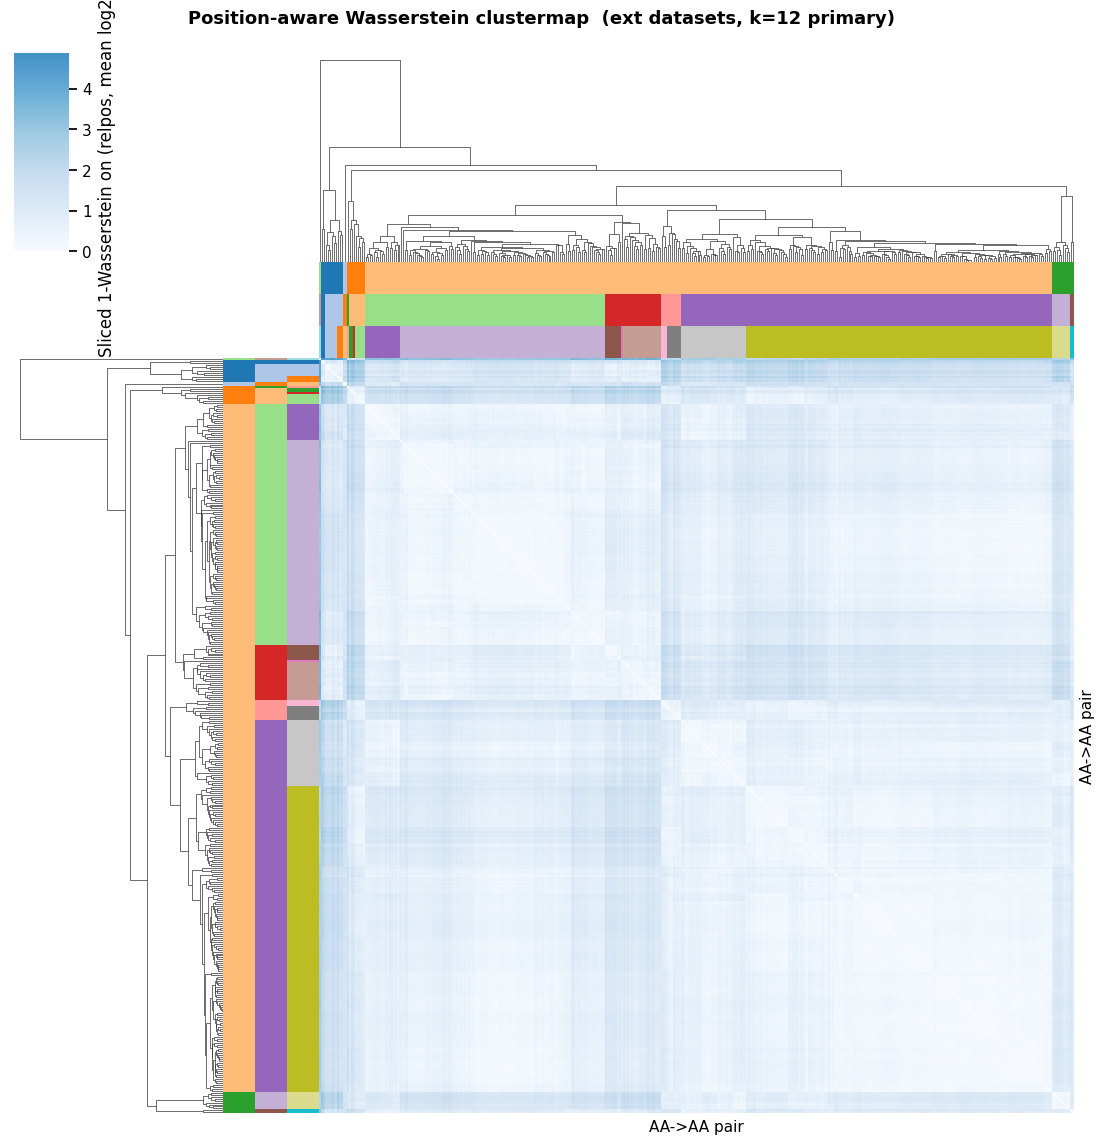

In [20]:
# Clustermap
dist_df_ext = pd.DataFrame(
    D_sw,
    index=[f"{a}>{b}" for a,b in pairs_ext],
    columns=[f"{a}>{b}" for a,b in pairs_ext],
)
row_color_levels_ext = []
for k in LEVELS:
    cl = clusters_by_level_ext[k]
    palette = sns.color_palette("tab20", n_colors=max(20, len(set(cl))))
    cmap_k = {c: palette[i % len(palette)] for i, c in enumerate(sorted(set(cl)))}
    row_color_levels_ext.append(pd.Series([cmap_k[c] for c in cl], name=f"k={k}"))

g = sns.clustermap(
    dist_df_ext, row_linkage=Z_ext, col_linkage=Z_ext,
    cmap=SOFT_BLUE,
    row_colors=row_color_levels_ext, col_colors=row_color_levels_ext,
    figsize=(11, 11),
    xticklabels=False, yticklabels=False,
    cbar_kws={"label": "Sliced 1-Wasserstein on (relpos, mean log2 ratio)"},
    linewidths=0,
)
g.ax_heatmap.set_xlabel("AA->AA pair", fontsize=11)
g.ax_heatmap.set_ylabel("AA->AA pair", fontsize=11)
g.figure.suptitle(
    f"Position-aware Wasserstein clustermap  (ext datasets, k={PRIMARY_K} primary)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.show()


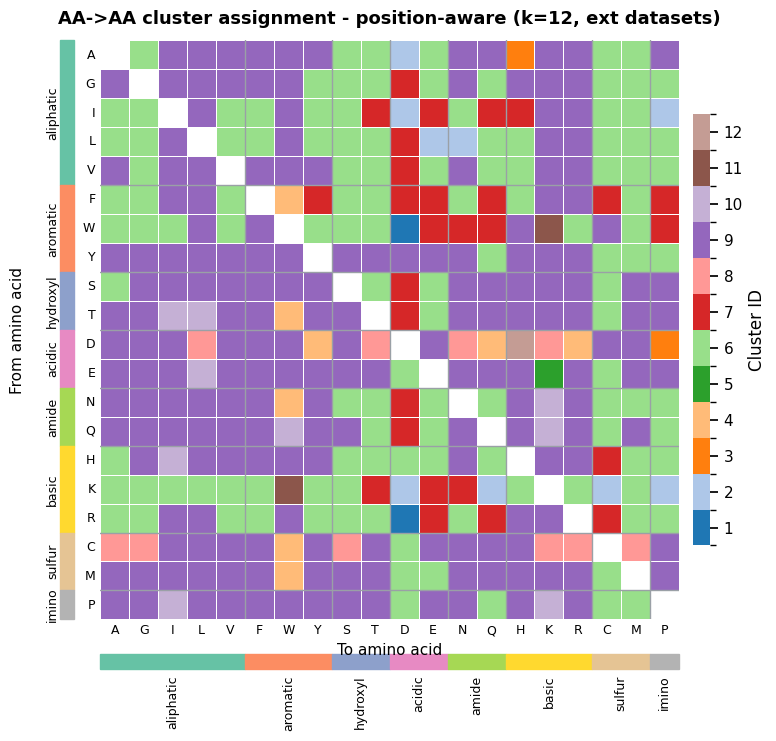

In [21]:
# 20x20 AA->AA cluster assignment (chemical_type grouping)
_ = plot_cluster_assignment(
    pairs_ext, primary_clusters_ext,
    classification="chemical_type",
    title=f"AA->AA cluster assignment - position-aware (k={PRIMARY_K}, ext datasets)",
)


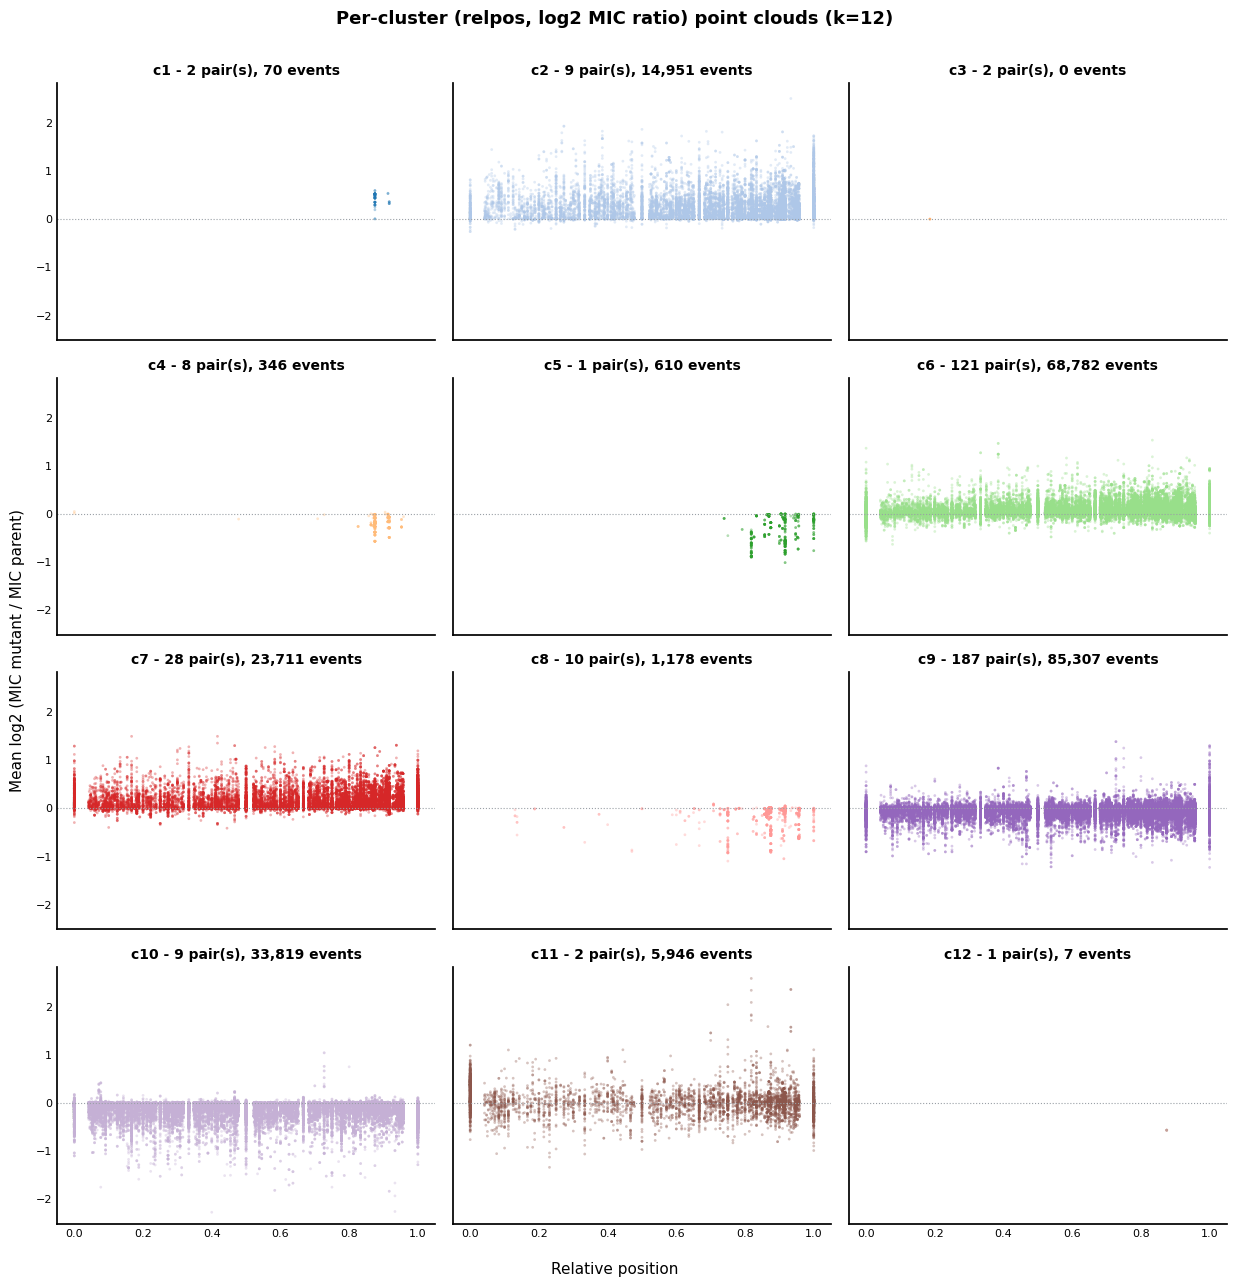

In [22]:
# Per-cluster 2D scatter of (relpos, mean log2 ratio) -- shows what each cluster looks like
def plot_cluster_clouds_2d(clouds, clusters, pairs, event_counts, iqr_axes):
    keys = sorted(set(clusters.tolist()))
    K = len(keys)
    ncols = 3
    nrows = int(np.ceil(K / ncols))
    palette = sns.color_palette("tab20", n_colors=max(20, K))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes).ravel()
    for ax, c in zip(axes, keys):
        members = [i for i, cc in enumerate(clusters) if cc == c]
        if not members:
            ax.axis("off"); continue
        all_pts = np.vstack([clouds[i] for i in members]) * iqr_axes  # undo IQR scaling for display
        n_evt = int(sum(event_counts[i] for i in members))
        ax.scatter(all_pts[:,0], all_pts[:,1], s=4, alpha=0.35,
                   color=palette[(c-1) % len(palette)], edgecolor="none")
        ax.axhline(0.0, color="#9aa0a6", lw=0.8, ls=":")
        ax.set_title(f"c{c} - {len(members)} pair(s), {n_evt:,} events",
                     fontsize=10, fontweight="bold")
        ax.tick_params(axis="both", labelsize=8, length=0)
        for spine in ("top","right"):
            ax.spines[spine].set_visible(False)
    for ax in axes[len(keys):]:
        ax.axis("off")
    fig.supxlabel("Relative position", fontsize=11)
    fig.supylabel("Mean log2 (MIC mutant / MIC parent)", fontsize=11)
    fig.suptitle(f"Per-cluster (relpos, log2 MIC ratio) point clouds (k={K})",
                 fontsize=13, fontweight="bold", y=1.0)
    fig.tight_layout()
    plt.show()

plot_cluster_clouds_2d(clouds_2d, primary_clusters_ext, pairs_ext, event_counts_ext, iqr)


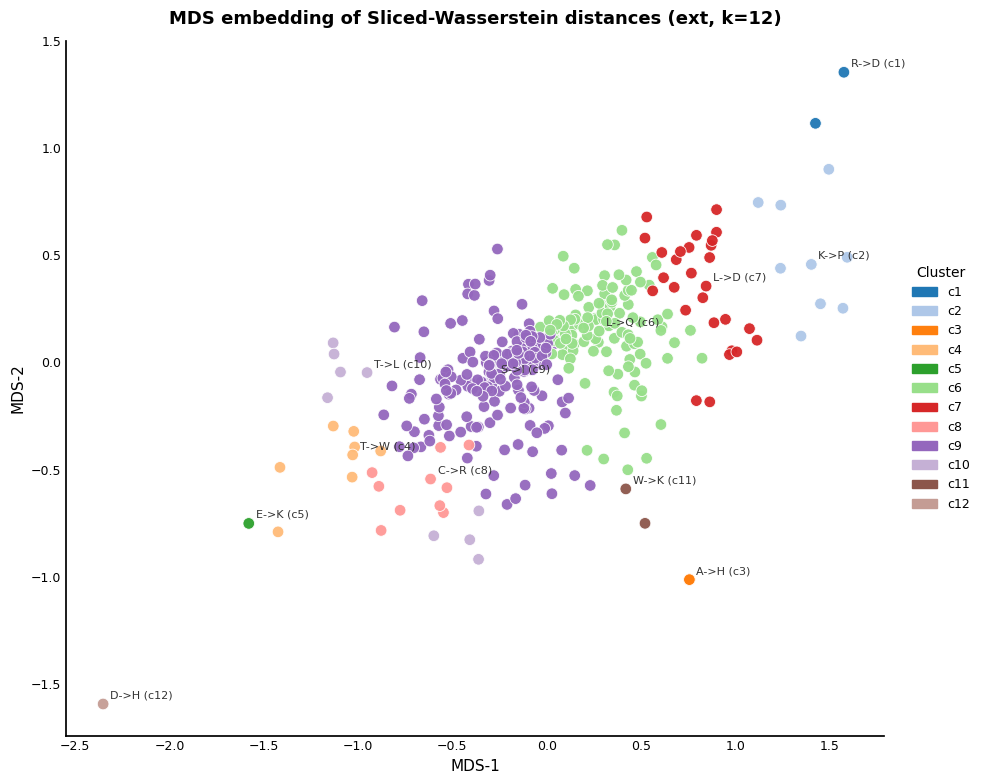

In [23]:
# MDS embedding of D_sw
mds_ext = MDS(n_components=2, dissimilarity="precomputed",
              random_state=0, n_init=4, normalized_stress="auto")
coords_ext = mds_ext.fit_transform(D_sw)

palette = sns.color_palette("tab20", n_colors=max(20, len(set(primary_clusters_ext))))
cluster_color = {c: palette[(c-1) % len(palette)] for c in sorted(set(primary_clusters_ext))}
colors_ext = [cluster_color[c] for c in primary_clusters_ext]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords_ext[:,0], coords_ext[:,1], c=colors_ext, s=70,
           edgecolor="white", linewidth=0.6, alpha=0.95)
for c in sorted(set(primary_clusters_ext)):
    mask = primary_clusters_ext == c
    if mask.sum() == 0: continue
    sub = coords_ext[mask]
    centroid = sub.mean(axis=0)
    closest = np.argmin(((sub - centroid)**2).sum(axis=1))
    i = np.where(mask)[0][closest]
    a, b = pairs_ext[i]
    ax.annotate(f"{a}->{b} (c{c})", (coords_ext[i,0], coords_ext[i,1]),
                xytext=(5, 4), textcoords="offset points", fontsize=8, color="#333")
ax.set_title(f"MDS embedding of Sliced-Wasserstein distances (ext, k={PRIMARY_K})",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("MDS-1", fontsize=11); ax.set_ylabel("MDS-2", fontsize=11)
ax.tick_params(axis="both", labelsize=9, length=0)
for spine in ("top","right"):
    ax.spines[spine].set_visible(False)
handles = [mpatches.Patch(color=cluster_color[c], label=f"c{c}")
           for c in sorted(set(primary_clusters_ext))]
ax.legend(handles=handles, title="Cluster", loc="center left",
          bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9, title_fontsize=10)
fig.tight_layout()
plt.show()


## 14.6 How much does adding position actually change the clustering?

We compare the position-aware distance matrix `D_sw` against the 1D-only matrix `D`
using Spearman correlation of their upper triangles and an adjusted-Rand index of the
two k=12 cluster assignments. A high Spearman with a low ARI would mean the *pairwise
ordering* is similar but the *partition* is reorganised.

In [24]:
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Re-align: the original D uses `pairs` order built from veltri_negative only, so it has
# the same ordering as pairs_ext (same nested loop over ALL_AA). Confirm:
assert pairs == pairs_ext, "Pair ordering mismatch between 1D and 2D pipelines"

iu = np.triu_indices(len(pairs), k=1)
rho, _ = spearmanr(D[iu], D_sw[iu])
ari = adjusted_rand_score(primary_clusters, primary_clusters_ext)
nmi = normalized_mutual_info_score(primary_clusters, primary_clusters_ext)

print(f"Spearman(D, D_sw) on upper-triangle:  rho = {rho:.3f}")
print(f"Adjusted Rand Index (k=12 partitions):  ARI = {ari:.3f}")
print(f"Normalised Mutual Information:           NMI = {nmi:.3f}")


Spearman(D, D_sw) on upper-triangle:  rho = 0.470
Adjusted Rand Index (k=12 partitions):  ARI = 0.167
Normalised Mutual Information:           NMI = 0.294


## 14.7 Summary table (position-aware clustering)

In [25]:
summary_rows_ext = []
for c in sorted(set(primary_clusters_ext)):
    members = [f"{a}>{b}" for (a,b), cc in zip(pairs_ext, primary_clusters_ext) if cc == c]
    pts = np.vstack([clouds_2d[i] * iqr for i, cc in enumerate(primary_clusters_ext) if cc == c])
    summary_rows_ext.append({
        "cluster":          int(c),
        "n_pairs":          len(members),
        "n_events":         int(sum(event_counts_ext[i] for i, cc in enumerate(primary_clusters_ext) if cc == c)),
        "mean_relpos":      round(float(pts[:,0].mean()), 3),
        "mean_log2_ratio":  round(float(pts[:,1].mean()), 3),
        "median_log2_ratio":round(float(np.median(pts[:,1])), 3),
        "examples": ", ".join(members[:8]) + (" ..." if len(members) > 8 else ""),
    })
summary_df_ext = pd.DataFrame(summary_rows_ext).sort_values("mean_log2_ratio").reset_index(drop=True)
summary_df_ext


,cluster,n_pairs,n_events,mean_relpos,mean_log2_ratio,median_log2_ratio,examples
0,12,1,7,0.875,-0.571,-0.571,D>H
1,5,1,610,0.904,-0.342,-0.293,E>K
2,4,8,346,0.881,-0.213,-0.197,"C>W, D>Q, D>R, D>Y, F>W, M>W, N>W, T>W"
3,8,10,1178,0.867,-0.186,-0.063,"C>A, C>G, C>K, C>M, C>R, C>S, D>K, D>L ..."
4,10,9,33819,0.549,-0.176,-0.111,"E>L, H>I, N>K, P>I, P>K, Q>K, Q>W, T>I ..."
5,9,187,85307,0.719,-0.052,-0.020,"A>F, A>I, A>K, A>L, A>N, A>P, A>Q, A>R ..."
6,3,2,0,0.186,0.000,0.000,"A>H, D>P"
7,11,2,5946,0.615,0.019,0.007,"K>W, W>K"
8,6,121,68782,0.728,0.063,0.031,"A>C, A>E, A>G, A>M, A>S, A>T, C>D, E>C ..."
9,7,28,23711,0.704,0.165,0.110,"F>C, F>D, F>E, F>P, F>Q, F>Y, G>D, H>C ..."
